In [14]:
import boto3
import os
import kagglehub
import random

from dotenv import load_dotenv

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from collections import Counter

In [15]:
# Initiera klienten 

load_dotenv()

rekognition = boto3.client(
    'rekognition', 
    region_name=os.getenv('AWS_REGION'), 
    aws_access_key_id=os.getenv('AWS_ACCESS_KEY'),
    aws_secret_access_key=os.getenv('AWS_SECRET_ACCESS_KEY')
)

In [16]:
# Ladda ner och extrahera datasetet
path = "All-Animals"

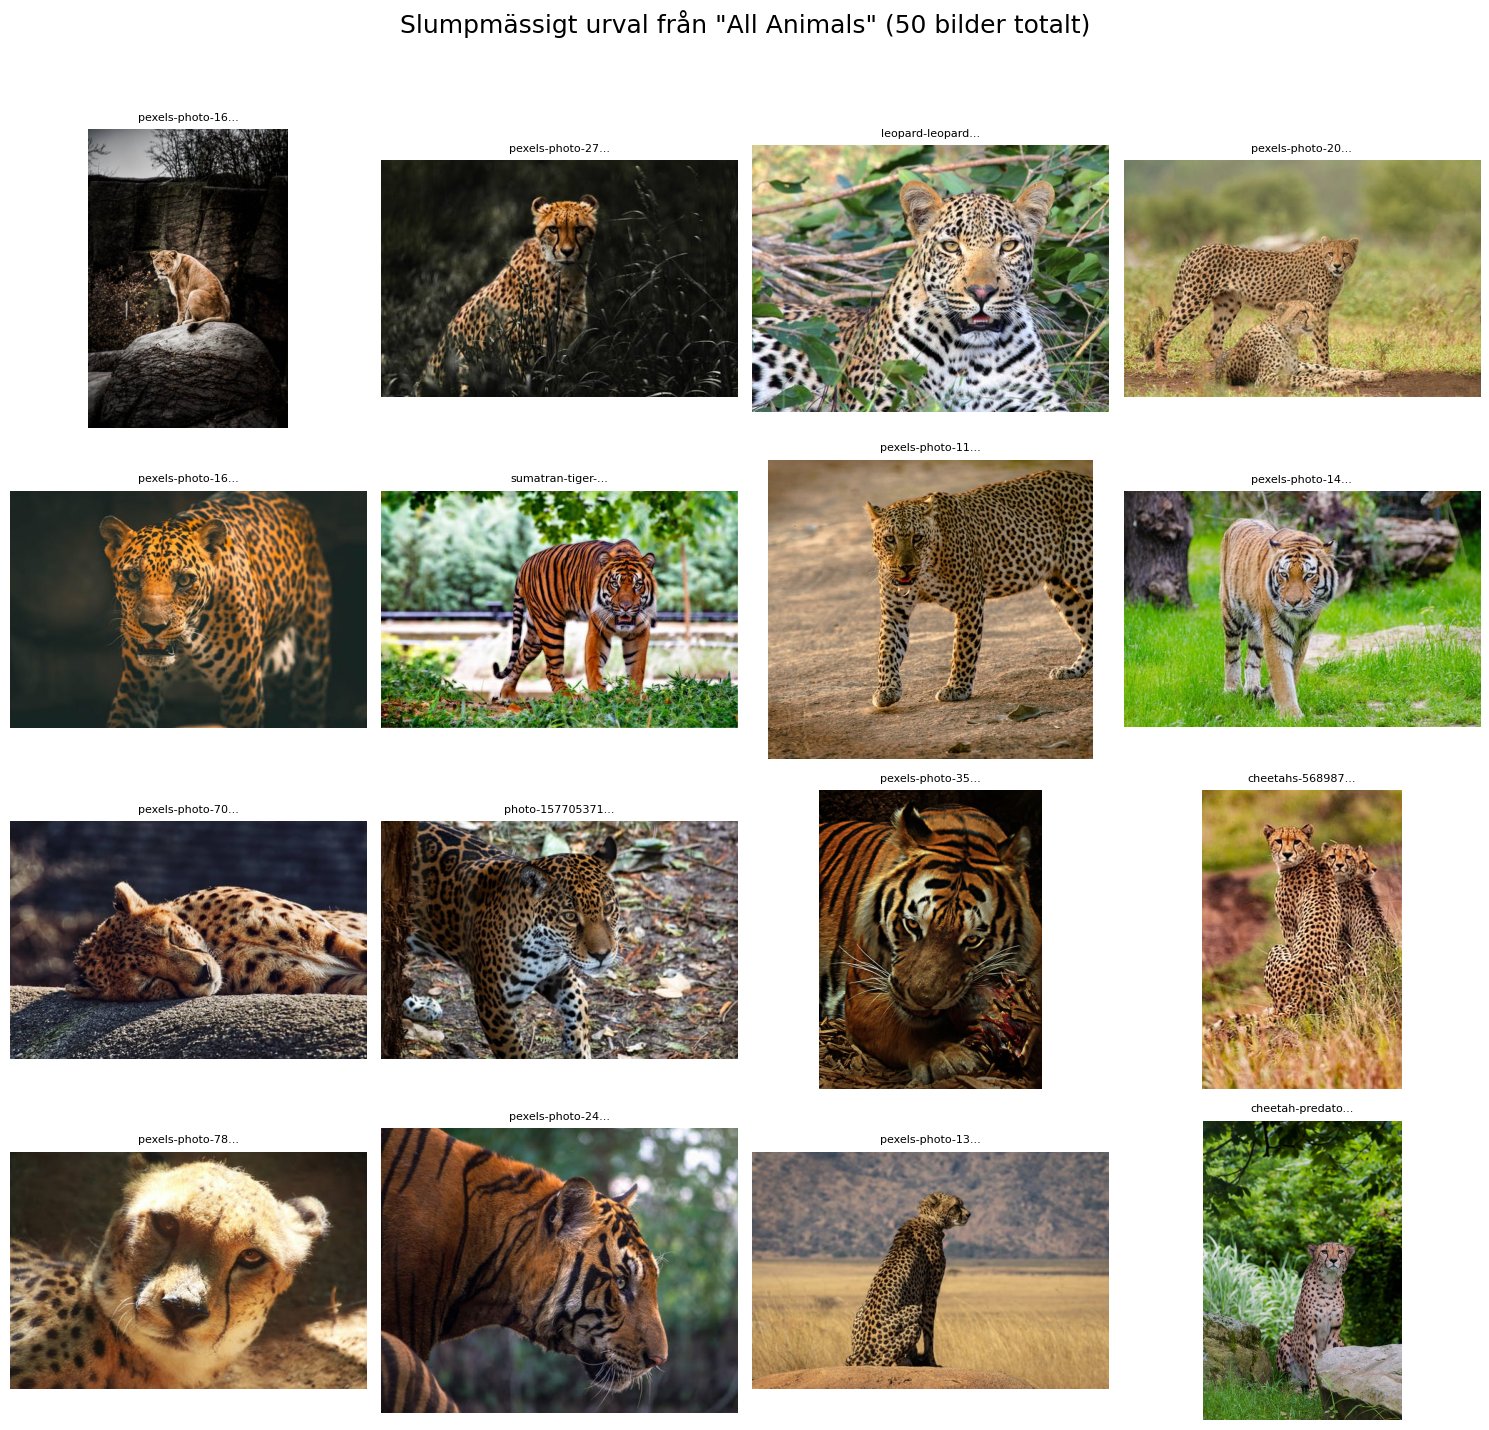

In [17]:
# 1. Inställningar - Vi pekar på din samlingsmapp
rows, cols = 4, 4
total_samples = rows * cols

# 2. Hämta alla bilder från den gemensamma mappen
if os.path.exists(path):
    all_images = [img for img in os.listdir(path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    # Slumpa fram bilder från hela datasetet
    sample_images = random.sample(all_images, min(total_samples, len(all_images)))

    # 3. Skapa rutnätet
    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    fig.suptitle(f'Slumpmässigt urval från "All Animals" ({len(all_images)} bilder totalt)', fontsize=18)

    for i, img_name in enumerate(sample_images):
        img_path = os.path.join(path, img_name)
        img_data = plt.imread(img_path)
        
        # Hitta rätt plats i rutnätet
        ax = axes[i // cols, i % cols]
        ax.imshow(img_data)
        ax.axis('off')
        
        # Valfritt: Visa filnamnet som en liten titel för att kunna identifiera bilden
        ax.set_title(img_name[:15] + "...", fontsize=8)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print(f"Kunde inte hitta mappen: {path}")

In [12]:
# 1. Inställningar
results = []

# 2. Hämta alla 50 bilder från mappen
images = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f"Hittade {len(images)} bilder i mappen: {path}\n")

# 3. Analys-loopen
for img_name in images:
    full_path = os.path.join(path, img_name)
    
    with open(full_path, 'rb') as f:
        image_data = f.read()
        
        response = rekognition.detect_labels(
            Image={'Bytes': image_data},
            MaxLabels=20,
            MinConfidence=55
        )
        
        labels = [label['Name'] for label in response['Labels']]
        results.append({'Folder': 'All-Animals', 'File': img_name, 'Labels': labels})
        print(f"  - {img_name}: {', '.join(labels)}")

print(f"\n--- Klart! Analyserade {len(results)} bilder ---")

Hittade 50 bilder i mappen: All-Animals

  - africa-animals-zoo-tiger.jpg: Animal, Zoo, Mammal, Panther, Wildlife, Cheetah, Ocelot, Tiger
  - animal-2607__340.jpg: Animal, Zoo, Mammal, Panther, Wildlife, Outdoors, Cheetah, Grass, Plant, Vegetation, Field, Grassland, Nature, Ocelot
  - cheetah-223734__340.jpg: Animal, Cheetah, Mammal, Wildlife, Zoo, Plant, Vegetation, Panther
  - cheetah-2268955__340.jpg: Animal, Cheetah, Mammal, Wildlife, Panther
  - cheetah-448901__480.jpg: Animal, Zoo, Cheetah, Mammal, Wildlife, Panther, Beak, Bird
  - cheetah-5689878__340.jpg: Animal, Cheetah, Mammal, Wildlife, Panther
  - cheetah-864747__340.jpg: Animal, Cheetah, Mammal, Wildlife, Panther, Plant, Vegetation, Zoo
  - cheetah-predator-wild-animal-speed-59952.jpeg: Animal, Cheetah, Mammal, Wildlife, Plant, Vegetation, Panther, Zoo
  - cheetahs-5689873__340.jpg: Animal, Cheetah, Mammal, Wildlife, Panther
  - cheetahs-cubs-two-together-162318.jpeg: Animal, Cheetah, Mammal, Wildlife, Grass, Plant, Zoo
  

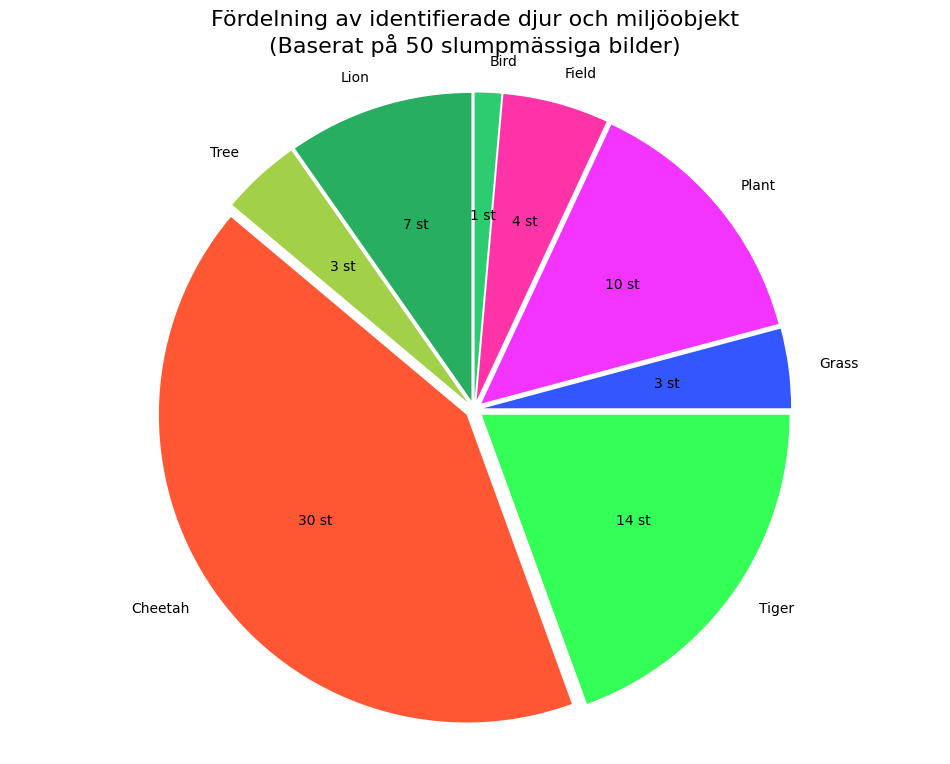

In [18]:
# 1. Definiera vilka objekt (djur och miljö) vi vill leta efter
target_objects = ['Cheetah', 'Jaguar', 'Leopard', 'Lion', 'Tiger', 'Grass', 'Plant', 'Field', 'Bird', 'Tree']

# Skapa en lista för att spara alla träffar
detected_items_list = []

# results antas vara definierad sedan tidigare
for res in results:
    for label in res['Labels']:
        if label in target_objects:
            detected_items_list.append(label)

# 2. Räkna förekomsten av varje objekt
object_counts = Counter(detected_items_list)
labels = list(object_counts.keys())
sizes = list(object_counts.values())

# 3. Skapa cirkeldiagrammet
plt.figure(figsize=(12, 9))

# Färger
colors = ['#FF5733', '#33FF57', '#3357FF', '#F333FF', '#FF33A8', 
          '#2ecc71', '#27ae60', '#a2d149', '#95a5a6']

# Rita diagrammet - Nu utan skugga!
plt.pie(sizes, 
        labels=labels, 
        autopct=lambda p: '{:.0f} st'.format(p * sum(sizes) / 100) if p > 0 else '', 
        startangle=140, 
        colors=colors[:len(labels)], 
        explode=[0.03]*len(labels), 
        shadow=False) # <--- HÄR tog vi bort skuggan!

plt.title('Fördelning av identifierade djur och miljöobjekt\n(Baserat på 50 slumpmässiga bilder)', fontsize=16)
plt.axis('equal') 

plt.show()